In [1]:
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from IPython.display import display
import ipywidgets as widgets
import sympy as sp
from scipy.stats import norm
import sympy as sp
import jax
import jax
import jax.numpy as jnp
from jax.scipy.special import ndtr
import os

%matplotlib ipympl




In [2]:
%load_ext jupyter_tikz

# Simulation of a Bernoulli Process

Each trial $X_t \sim \text{Bernoulli}(p)$:

$$X_t = \begin{cases} 1 & \text{with probability } p \\ 0 & \text{with probability } 1-p \end{cases}$$

The counting process (cumulative sum):

$$N_t = \sum_{i=1}^{t} X_i, \quad \mathbb{E}[N_t] = pt, \quad \text{Var}(N_t) = p(1-p)t$$



P(goal) = 0.1


In [3]:
rng = np.random.default_rng()

def simulate_goal(simulations,minute):

    time_range = np.arange(0,minute + 1)

    sim_results = []

    for _ in range(simulations):
        goals_per_minute = rng.choice([1,0], size = minute, p = [0.1,0.9])
        cumulative = np.cumsum(goals_per_minute)
        cumulative = np.insert(cumulative,0,0)
        sim_results.append(cumulative)

    return sim_results


def simulate_and_plot_goal_simulation(simulations, minute):

    time_range = np.arange(0,minute + 1)

    data = simulate_goal(simulations,minute)

    for simulation in range(simulations):
         plt.step(time_range, data[simulation] , where='post')

    plt.xlabel('Minutes')
    plt.ylabel('Goals')
    plt.xticks([0, 30, 60, 90])
    plt.tight_layout()
    plt.show()






In [4]:
simulate_goal(1,90)

[array([0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 3, 3, 3, 4, 4, 4, 4, 5, 5, 5, 5, 5,
        5, 5, 5, 5, 5, 5, 5, 5, 6, 6, 6, 6, 7, 8, 8, 8, 8, 8, 8, 8, 8, 8,
        8, 8, 8])]

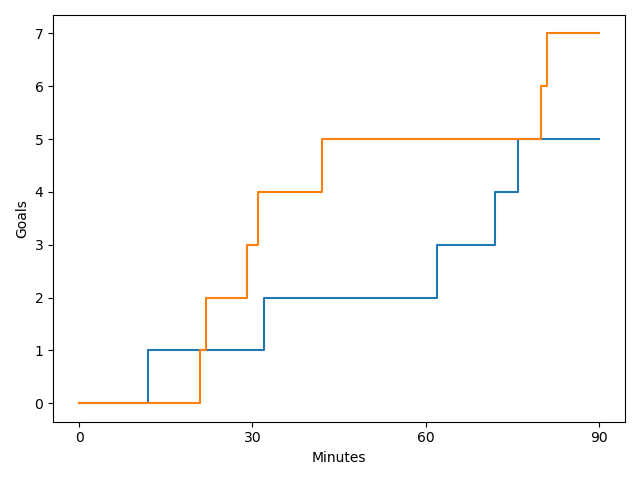

In [5]:
simulate_and_plot_goal_simulation(2, 90)

In [6]:
def simulate_and_animate(simulations, minute, sim_results=None):
    time_range = np.arange(0, minute + 1)

    if sim_results is None:
        print("sim results was none")
        sim_results = simulate_goal(simulations, minute)


    fig, ax = plt.subplots()
    ax.set_xlim(0, minute)
    ax.set_ylim(0, max(arr[-1] for arr in sim_results) + 1)
    ax.set_xlabel("Minute")
    ax.set_ylabel("Goals")

    lines = [ax.plot([], [], alpha=0.6)[0] for _ in range(simulations)]

    def update(frame):
        ax.set_title(f"Minute: {frame}")
        for i, line in enumerate(lines):
            line.set_data(time_range[:frame+1], sim_results[i][:frame+1])
        return lines

    anim = FuncAnimation(
        fig,
        update,
        frames=len(time_range),
        interval=50,   # her frame arası kaç ms beklesin
        blit=True,
        repeat=False,
    )

    plt.show()
    return anim



sim results was none


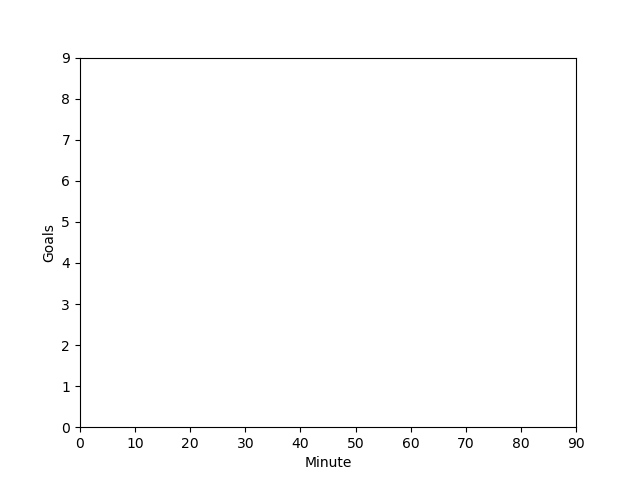

In [7]:
simulate_and_animate(1, 90)

In [8]:
def simulate_and_animate_slider(simulations, minute, sim_results=None):
    time_range = np.arange(0, minute + 1)

    if sim_results is None:
        print("sim results was none")
        sim_results = simulate_goal(simulations, minute)

    fig, ax = plt.subplots()
    ax.set_xlim(0, minute)
    ax.set_ylim(0, max(arr[-1] for arr in sim_results) + 1)
    ax.set_xlabel("Minute")
    ax.set_ylabel("Goals")

    lines = [ax.plot([], [], alpha=0.6)[0] for _ in range(simulations)]

    def update(frame):
        ax.set_title(f"Minute: {frame}")
        for i, line in enumerate(lines):
            line.set_data(time_range[:frame+1], sim_results[i][:frame+1])
        fig.canvas.draw()

    slider = widgets.IntSlider(min=0, max=minute, step=1, value=0, description="Minute")
    widgets.interact(update, frame=slider)
    plt.show()

sim results was none


interactive(children=(IntSlider(value=0, description='Minute', max=90), Output()), _dom_classes=('widget-inter…

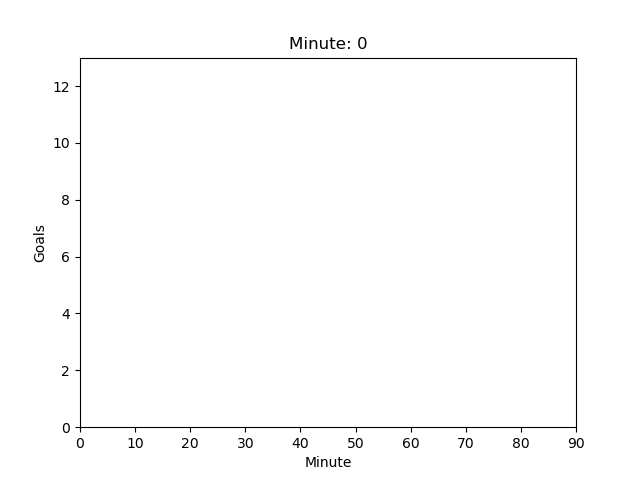

In [9]:
simulate_and_animate_slider(5, 90)


# Simulation of Random Walk


$$S_0 = 0, \qquad S_t = \sum_{i=1}^{t} \xi_i$$

where each step $\xi_i$ is symmetric Bernoulli:

$$\xi_i = \begin{cases} +1 & \text{with probability } \frac{1}{2} \\ -1 & \text{with probability } \frac{1}{2} \end{cases}$$

Properties:

$$\mathbb{E}[S_t] = 0, \qquad \text{Var}(S_t) = t$$





#### Switch from NumPY to jax and how their randomness work:
- seeds determine the first element of random generator, then a function (Mersenne Twister for numpy or Threefry/Philox for JAX) called on that seed.
    - Same seed: always same set of numbers.

- 'rng = np.random.default_rng()' was generating a random seed + STATE(called key in jax).
    - with each call of random generation DIFFERENT number (another iteration in set) is returned.
        - that is enabled by the fact that this key is changing

- key = jax.random.PRNGKey(42)
    - seed = state. state is not updating itself like numpy, thereby can not be set once and then reused.
        - same key  same random number
        - 'key, subkey = jax.random.split(key)' key is changed explicitly.
        - yet, as split is deterministic, just saving the start key/seed is enough for reproductibility


In [10]:
key = jax.random.PRNGKey(42)
key

Array([ 0, 42], dtype=uint32)

In [11]:
jax.random.normal(key)

Array(-0.02830462, dtype=float32)

In [12]:
jax.random.normal(key)

Array(-0.02830462, dtype=float32)

In [13]:

key = jax.random.PRNGKey(int.from_bytes(os.urandom(4), 'big'))
print("jax key = " + str(key))

@jax.jit
def simulate_random_walk(key, simulations, minute):
    keys = jax.random.split(key, simulations)

    def single_walk(k):
        steps = jax.random.choice(k, jnp.array([-1, 1]), shape=(minute,))
        cumulative = jnp.cumsum(steps)
        return jnp.concatenate([jnp.array([0]), cumulative])

    return jax.vmap(single_walk)(keys)  # shape: (simulations, minute+1)

results = simulate_random_walk(key, simulations=100, minute=90)

jax key = [         0 2719138439]


TypeError: As of JAX v0.7, parameters to jaxpr equations must have __hash__ and __eq__ methods. In a call to primitive random_split, the value of parameter shape was not hashable: (JitTracer(~int32[]),)

# Brownian Motion

- starts at zero
- continious function in time
- increments are normally distrubited with mean of zero and variance of distance of increment $ \sim \mathcal{N}(0, s - u) $
- independent of what happened before ( $z(s) - z(u)$ is independentend before u)

# Black Scholes Equation

$$
\underbrace{\frac{\partial C}{\partial t}}_{\text{Theta}}
+
\frac{1}{2}\sigma^2 S^2
\underbrace{\frac{\partial^2 C}{\partial S^2}}_{\text{Gamma}}
+
rS \underbrace{\frac{\partial C}{\partial S}}_{\text{Delta}}
- rC = 0
$$

* $C = C(S, t)$ : option price — a function of stock price $S$ and time $t$
* $S = S(t)$ : stock price at time $t$
* $\sigma$ : standard deviation of log returns
* $r$ : risk-free interest rate
* $\frac{\partial C}{\partial t}$ : rate of change of option price with respect to time (Theta)
* $\frac{\partial C}{\partial S}$ : rate of change of option price with respect to stock price (Delta)
* $\frac{\partial^2 C}{\partial S^2}$ : rate of change of Delta with respect to stock price (Gamma)

# Black Scholes Formula

* $S_0$ : (current) stock price
* $C_0$ : (current) call option price
* $X$ : Exercise/Strike Price (price at we have right to buy)
* $T$ : time to expiration
* $r$ : risk free interest rate
* $ \sigma$ : standart deviation of LOG RETURNS




$$C_0 = S_0 N(d_1) - X e^{-rT} N(d_2)$$

$$d_1 = \frac{\ln\left(\frac{S_0}{X}\right) + \left(r + \frac{\sigma^2}{2}\right)T}{\sigma\sqrt{T}}$$

$$d_2 = \frac{\ln\left(\frac{S_0}{X}\right) + \left(r - \frac{\sigma^2}{2}\right)T}{\sigma\sqrt{T}}$$




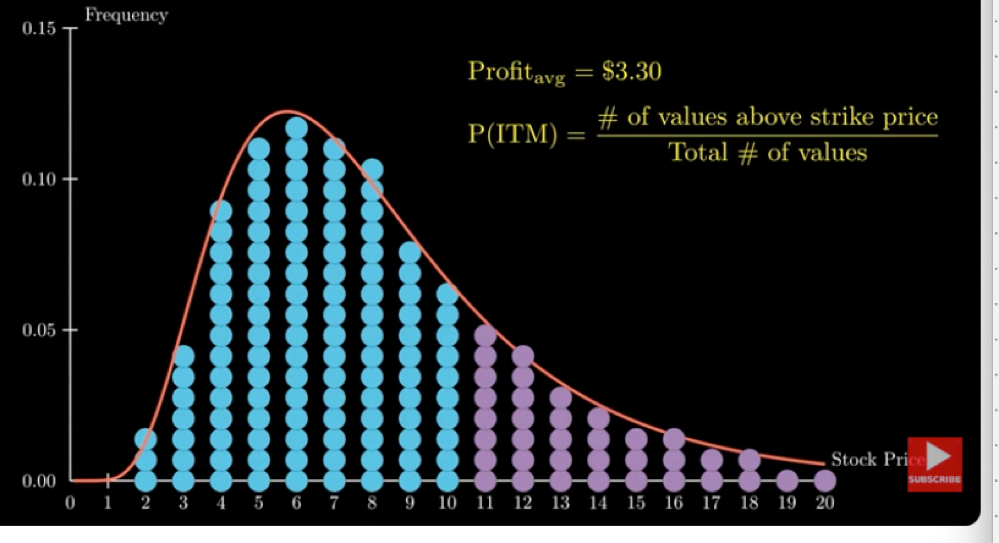

* goal: finding call options fair price at the moment t = 0, $c_0$

* $$
C_0 = \underbrace{S_0 N(d_1)}_{\text{expected gain }} - \underbrace{X e^{-rT} N(d_2)}_{\text{expected cost (present value)}}
$$


* $$
d_1 = \frac{\underbrace{\ln\left(\frac{S_0}{X}\right)}_{\text{distance to strike}} + \underbrace{\left(r + \frac{\sigma^2}{2}\right)T}_{\text{drift + convexity adjustment}}}{\underbrace{\sigma\sqrt{T}}_{\text{normalizer}}}
$$

* $$
d_2 = \underbrace{d_1 - \sigma\sqrt{T}}_{\text{d}_1 \text{ without convexity adjustment}}
$$

* $d2$ = how many standard deviations away the stock's expected (risk-neutral) log-return is from the breakeven point.

* why log return = We assume stock prices are lognormally distrubited.
* log return = just return (profit or loss) expressed in logatimic term.
    * normaly, our return would be (WHEN THE OPTION IS EXCERSISED) $return at t=0 = S_0 - X$
    * in log format: $\ln S_0 - \ln X = \ln\left(\frac{S_0}{X}\right)$
    * rT = drift adjustment, as there is no arbitrage the value should grow every year.
    * $\sigma^2/2$ convexity adjustment, as lognormal distrubitions mean is not $\mu$ but $\mu - \sigma^2/2$
    * $\sigma\sqrt{T}$ standart deviation of lognormal distrubution.
        * as we are willing to calculate the possibility of expected value happening

* $N(d2)$ =  probability that the option expires in-the-money — i.e., S_T > X under the risk-neutral measure.


* N(d1) = IIf the stock price increases by $1, how much does the option price increase?


#### d1 vs d2
* N(d2) asks: will the stock cross the strike? → each scenario counts equally
    * doesnt matter how much higher stock expires
* N(d1) asks: will the stock cross the strike, and how far? → scenarios where $S_T$ is very high get more weight, because **you're receiving the stock itself, not just a binary $1 payout**

#### C_0s value at expiration and present value

$$C_t^{\text{expiration}} = \underbrace{S_t e^{rt} N(d_1)}_{\text{average profit at expiration}} - \underbrace{XN(d_2)}_{\text{average price paid at expiration}}$$

* taking NPV with continious compounding:
$$C_0 = e^{-rt} \cdot C_t^{\text{expiration}} = e^{-rt} \left[ \underbrace{S_t e^{rt} N(d_1)}_{\text{average profit at expiration}} - \underbrace{XN(d_2)}_{\text{average price paid at expiration}} \right]$$

$$ \boxed{C_0 = S_t N(d_1) - Xe^{-rt} N(d_2)} $$







#### Assumptions

- Stock prices are lognormally distributed (log returns are normal)
- Volatility σ is constant over the option's life
- Risk-free rate r is constant
- No dividends paid during the option's life
- European option — exercise only at expiry
- No transaction costs or taxes
- No arbitrage opportunities exist
- Continuous trading is possible

## The Greeks

### Delta ($\Delta$)
Sensitivity of the option price to changes in the underlying asset’s price.

- Definition: $\Delta = \dfrac{\partial V}{\partial S}$, sensitivity of option price to changes in the underlying price
- Interpretation: **hedge ratio, i.e. units of underlying needed to delta-hedge the option**
    - How much of the asset we should buy to

- Range: call options $0 \leq \Delta \leq 1$, put options $-1 \leq \Delta \leq 0$
- At-the-money (ATM) options have $\Delta \approx 0.5$
- Deep in-the-money (ITM) options approach $\Delta \to 1$ (calls) or $\Delta \to -1$ (puts)
- Deep out-of-the-money (OTM) options approach $\Delta \to 0$

### Theta ($\Theta$)
Sensitivity to the passage of time (time decay).

- Definition: $\Theta = \dfrac{\partial V}{\partial t}$, sensitivity to the passage of time
- Usually negative for long option positions: time decay erodes the option's time value
- Decay is non-linear, accelerating as expiration approaches, especially for ATM options
- Long option positions lose value from theta; short positions gain from it
- Relationship: theta and gamma often move in opposite directions in a hedged portfolio (the "theta-gamma tradeoff")

### Vega ($\nu$)
Sensitivity to implied volatility.

- Definition: $\nu = \dfrac{\partial V}{\partial \sigma}$, sensitivity to implied volatility
- **Positive for both calls and puts: higher volatility increases the value of optionality**
    - INCREASED VOLATILITY, INCREASES THE TAILS OF OPTIONS EXPECTED RETURNS AND IT MAKES THE HOLDER BETER OFF
- Highest for ATM options, decreases for deep ITM/OTM options
- Particularly important in stochastic volatility models (e.g. Heston) where $\sigma$ itself is not constant


## #Rho ($\rho$)
Sensitivity to the interest rate.

- Definition: $\rho = \dfrac{\partial V}{\partial r}$, sensitivity to the risk-free interest rate
- Positive for call options, negative for put options
- Generally smaller in magnitude for short-dated options
- Becomes more significant for long-dated options (e.g. LEAPS) or in high-rate environments

### Gamma ($\Gamma$)
(Second order) Sensitivity of delta to changes in the underlying price.

- Definition: $\Gamma = \dfrac{\partial^2 V}{\partial S^2} = \dfrac{\partial \Delta}{\partial S}$, second-order sensitivity of price to the underlying
- Measures how fast delta changes as the underlying moves
- Highest for ATM options, lower for deep ITM/OTM options
- High gamma implies frequent delta-hedge rebalancing, a key concern for market makers
- Basis for gamma scalping strategies


In [ ]:
@jax.jit
def black_scholes_call(S0, X, T, r, sigma):
    """
    European Call Option Price via Black-Scholes (JAX).

    Args:
        S0    : Current stock price
        X     : Strike price
        T     : Time to expiration (in years)
        r     : Risk-free interest rate
        sigma : Volatility (std dev of log returns)

    Returns:
        C0    : Call option price
    """

    d1 = (jnp.log(S0 / X) + (r + 0.5 * sigma**2) * T) / (sigma * jnp.sqrt(T))
    d2 = d1 - sigma * jnp.sqrt(T)

    C0 = S0 * ndtr(d1) - X * jnp.exp(-r * T) * ndtr(d2)
    return C0

In [ ]:
price = black_scholes_call(S0=100.0, X=105.0, T=1.0, r=0.05, sigma=0.2)

In [ ]:
price

Calculating prices for different strikes at once with JAX vectorisation


In [ ]:
strikes = jnp.array([90., 95., 100., 105., 110.])

In [ ]:
prices = black_scholes_call(S0=100.0, X=strikes, T=1.0, r=0.05, sigma=0.2)

In [ ]:
prices

# Monte Carlo Pricing via Simulated Brownian Motion

Instead of solving the Black-Scholes PDE in closed form, we can **simulate** the underlying stock price under the risk-neutral measure and estimate the option price as a discounted expected payoff. This connects directly back to the "Brownian Motion" section above.

### From Brownian motion to the stock price (GBM)

Under the risk-neutral measure $\mathbb{Q}$, the stock price follows Geometric Brownian Motion:

$$dS_t = r S_t \, dt + \sigma S_t \, dW_t$$

where $W_t$ is a standard Brownian motion ($W_0 = 0$, independent normal increments $W_t - W_s \sim \mathcal{N}(0, t-s)$, as defined above).

Applying Ito's Lemma to $\ln S_t$ gives the closed-form **solution** of this SDE:

$$S_t = S_0 \exp\left( \left(r - \frac{\sigma^2}{2}\right)t + \sigma W_t \right)$$

So simulating the stock price path is really just:
1. Simulate a standard Brownian motion path $W_t$ (cumulative sum of $\mathcal{N}(0, dt)$ increments).
2. Plug it into the exponential formula above.

### Monte Carlo estimator

By risk-neutral valuation, the fair call price is the discounted expectation of the terminal payoff:

$$C_0 = e^{-rT}\, \mathbb{E}^{\mathbb{Q}}\big[\max(S_T - X, 0)\big] \approx e^{-rT} \cdot \frac{1}{N}\sum_{i=1}^{N} \max\!\big(S_T^{(i)} - X,\, 0\big)$$

Because $W_t$ has *independent* increments, $W_T \sim \mathcal{N}(0, T)$ directly — we don't need to walk through every intermediate time step to get $S_T$, only to *visualize* a full path.

In [ ]:
from functools import partial

@partial(jax.jit, static_argnames=("simulations", "steps"))
def simulate_gbm_paths(key, simulations, steps, T, S0, r, sigma):
    """
    Simulate stock price paths by discretizing a standard Brownian motion
    and mapping it through the closed-form GBM solution.

    Args:
        key         : JAX PRNG key
        simulations : number of independent paths (static)
        steps       : number of time steps per path (static)
        T           : time to expiration (years)
        S0, r, sigma: Black-Scholes parameters

    Returns:
        t_grid : (steps+1,) time grid, t_grid[0] = 0
        S      : (simulations, steps+1) simulated stock price paths, S[:, 0] = S0
    """
    dt = T / steps
    t_grid = jnp.linspace(0.0, T, steps + 1)

    # Brownian increments dW ~ N(0, dt)  <=>  Z * sqrt(dt), Z ~ N(0, 1)
    Z = jax.random.normal(key, shape=(simulations, steps))
    dW = jnp.sqrt(dt) * Z

    # standard Brownian motion path: W_0 = 0, W_t = sum of increments up to t
    W = jnp.concatenate([jnp.zeros((simulations, 1)), jnp.cumsum(dW, axis=1)], axis=1)

    # GBM stock price path from the closed-form SDE solution
    S = S0 * jnp.exp((r - 0.5 * sigma**2) * t_grid + sigma * W)

    return t_grid, S

In [ ]:
key = jax.random.PRNGKey(int.from_bytes(os.urandom(4), 'big'))

S0, X, T, r, sigma = 100.0, 105.0, 1.0, 0.05, 0.2
t_grid, sample_paths = simulate_gbm_paths(key, simulations=30, steps=252, T=T, S0=S0, r=r, sigma=sigma)

plt.figure()
for path in sample_paths:
    plt.plot(t_grid, path, alpha=0.5)
plt.axhline(X, color='black', linestyle='--', label=f'Strike X={X}')
plt.xlabel('Time (years)')
plt.ylabel('Stock price')
plt.title('Simulated GBM paths (from Brownian motion)')
plt.legend()
plt.tight_layout()
plt.show()

### Pricing: only $S_T$ matters

A European call only pays off at $T$, so for *pricing* we don't need the full path — a single step (`steps=1`) from $0$ to $T$ gives an exact sample of $S_T$, and is far cheaper than simulating hundreds of intermediate steps.

We also track the **standard error** of the Monte Carlo estimate, since it's a random estimator and not exact like the closed-form formula:

$$\text{SE} = \frac{\text{std}(\text{discounted payoffs})}{\sqrt{N}}, \qquad \text{95% CI} = \hat{C}_0 \pm 1.96 \cdot \text{SE}$$

In [ ]:
@partial(jax.jit, static_argnames=("simulations",))
def black_scholes_call_mc(key, S0, X, T, r, sigma, simulations=200_000):
    """
    Monte Carlo price of a European call: simulate Brownian motion,
    map to S_T via GBM, discount the average payoff.

    Returns:
        price : Monte Carlo estimate of C0
        ci95  : half-width of the 95% confidence interval
    """
    _, S = simulate_gbm_paths(key, simulations, 1, T, S0, r, sigma)
    S_T = S[:, -1]

    discounted_payoff = jnp.exp(-r * T) * jnp.maximum(S_T - X, 0.0)

    price = jnp.mean(discounted_payoff)
    ci95 = 1.96 * jnp.std(discounted_payoff) / jnp.sqrt(simulations)

    return price, ci95

In [ ]:
key = jax.random.PRNGKey(int.from_bytes(os.urandom(4), 'big'))

mc_price, ci95 = black_scholes_call_mc(key, S0=S0, X=X, T=T, r=r, sigma=sigma, simulations=500_000)
analytical_price = black_scholes_call(S0=S0, X=X, T=T, r=r, sigma=sigma)

print(f"Monte Carlo price   : {mc_price:.4f}  (95% CI: +/- {ci95:.4f})")
print(f"Analytical BS price : {analytical_price:.4f}")

### Convergence (Law of Large Numbers)

As $N \to \infty$, the Monte Carlo estimate converges to the true price at a rate of $O(1/\sqrt{N})$. Plotting the running mean of discounted payoffs against the number of simulations shows this convergence directly.

In [ ]:
key = jax.random.PRNGKey(int.from_bytes(os.urandom(4), 'big'))

N = 200_000
_, S = simulate_gbm_paths(key, N, 1, T, S0, r, sigma)
discounted_payoff = jnp.exp(-r * T) * jnp.maximum(S[:, -1] - X, 0.0)

running_mean = jnp.cumsum(discounted_payoff) / jnp.arange(1, N + 1)

plt.figure()
plt.plot(running_mean, label='Monte Carlo running estimate')
plt.axhline(float(analytical_price), color='black', linestyle='--', label='Analytical Black-Scholes price')
plt.xlabel('Number of simulations')
plt.ylabel('Call option price')
plt.legend()
plt.tight_layout()
plt.show()